# Inspecting the detector on the organisers' labelled test series

One hundred series with known break positions, scored by the 40-channel model
exactly as the platform would run it — one observation at a time, no lookahead.
Every figure follows the same layout: **raw series** with the true break in
red, **normalised stream** the detectors actually see, and the **model score**
with the break marked again. The vertical grey line is the history/online
boundary.

Sorted galleries first (best, median, worst), then slices by the character of
the series — trend, dispersion, dependence, tail weight, break position — which
is where hypotheses about the next model come from.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

WS = Path("../../structural-break-real-time-test")
sys.path.insert(0, str(WS))  # the submission module, exactly as shipped

import importlib.util
spec = importlib.util.spec_from_file_location(
    "submission", Path("../submissions/008-reverting-channels/main.py")
)
submission = importlib.util.module_from_spec(spec)
# Registered before execution: the module defines dataclasses, and dataclass
# field resolution looks itself up in sys.modules -- an unregistered module
# crashes there with an AttributeError three frames deep.
sys.modules["submission"] = submission
spec.loader.exec_module(submission)

x = pd.read_parquet(WS / "data/X_test.reduced.parquet")
y = pd.read_parquet(WS / "data/y_test.reduced.parquet")
models = {
    "005": joblib.load("../../model005_backup.joblib")["booster"],   # 40 каналов
    "006": joblib.load("../../model006.joblib")["booster"],          # 41, +CNN
    "008": joblib.load("../../resources008/model.joblib")["booster"],  # 50, +ревертируемые
}
model = models["008"]  # лучшая: сортировка и метрики считаются по ней
print(f"{x.index.get_level_values(0).nunique()} series; models:",
      {k: m.n_features_ for k, m in models.items()})

100 series; models: {'005': 40, '006': 41, '008': 50}


In [2]:
# Score every series step by step, storing everything the figures need.
records = {}
for sid, part in x.groupby(level="id"):
    hist = part.loc[part.period == 1, "value"].to_numpy()
    online = part.loc[part.period == 2, "value"].to_numpy()
    if len(online) == 0:
        continue
    labels = y.loc[sid, "target"].to_numpy()
    monitor = submission.Monitor(hist)
    channels = np.asarray([monitor.update(float(v)) for v in online])
    # Первые 40 колонок — вектор 005, первые 41 — 006: порядок каналов только
    # дописывался в конец, так что одна прогонка кормит все модели.
    all_scores = {
        name: m.predict_proba(channels[:, : m.n_features_])[:, 1]
        for name, m in models.items()
    }
    scores = all_scores["008"]
    norm = monitor.norm
    z_online = np.asarray(
        [norm.clip(norm.standardise(float(v), i)) for i, v in enumerate(online)]
    )
    z_hist = np.asarray(
        [norm.clip(norm.standardise(float(v), -len(hist) + i)) for i, v in enumerate(hist)]
    )
    tau = int(labels.argmax()) if labels.max() > 0 else None
    # Where the model itself calls the break: the first step at which the score
    # crosses half of its own maximum on this series. A display convention, not
    # part of the metric -- the metric never asks for a point -- but a figure
    # without it leaves the reader guessing where the purple line "decided".
    detected_by = {}
    for name, sc in all_scores.items():
        peak = float(sc.max())
        crossed = np.flatnonzero(sc >= 0.5 * peak) if peak > 0 else []
        detected_by[name] = int(crossed[0]) if len(crossed) else None
    detected = detected_by["008"]
    # Отмена тревоги (умеет только 008): счёт падает ниже половины своего
    # достигнутого максимума после того, как тревога была поднята всерьёз.
    running = np.maximum.accumulate(scores)
    alarmed = running >= 0.6 * float(scores.max()) if scores.max() > 0 else running > 1
    below = scores < 0.5 * running
    cross_down = below & ~np.roll(below, 1) & alarmed
    cross_down[0] = False
    cancellations = np.flatnonzero(cross_down)
    records[int(sid)] = dict(
        hist=hist, online=online, z=z_online, z_hist=z_hist, scores=scores,
        channels=channels,
        labels=labels, tau=tau, detected=detected,
        all_scores=all_scores, detected_by=detected_by, cancellations=cancellations,
        slope=norm.slope, sd=norm.sd, rho=norm.rho, kurt=norm.kurtosis,
    )
print(f"scored {len(records)} series")

scored 100 series


In [3]:
# Per-series quality. For a broken series: the within-series AUC of the score
# against the per-step label -- does the score rank post-break steps above
# pre-break ones. For an unbroken series: the false-alarm level, taken as the
# final score (lower is better). The two are different questions, so the
# galleries are sorted separately.
def within_auc(scores, labels):
    pos, neg = scores[labels == 1], scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan
    ranks = np.concatenate([pos, neg]).argsort().argsort() + 1
    return (ranks[: len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))

rows = []
for sid, r in records.items():
    rows.append(dict(
        id=sid, broken=r["tau"] is not None, tau=r["tau"],
        n_online=len(r["online"]),
        quality=within_auc(r["scores"], r["labels"]) if r["tau"] is not None else np.nan,
        false_alarm=float(r["scores"][-1]) if r["tau"] is None else np.nan,
        trend=abs(r["slope"]) * len(r["hist"]) / r["sd"],
        sd=r["sd"], rho=r["rho"], kurt=r["kurt"],
    ))
table = pd.DataFrame(rows).set_index("id")
print(table.groupby("broken").size())
broken = table[table.broken].sort_values("quality", ascending=False)
clean = table[~table.broken].sort_values("false_alarm")
print(f"broken: median within-series AUC {broken.quality.median():.3f}")
print(f"clean:  median final score {clean.false_alarm.median():.3f}")

broken
False    47
True     53
dtype: int64
broken: median within-series AUC 0.973
clean:  median final score 0.320


In [4]:
def show(sid, title_extra=""):
    r = records[sid]
    hist, online, z, scores, tau = r["hist"], r["online"], r["z"], r["scores"], r["tau"]
    z_hist, detected = r["z_hist"], r["detected"]
    all_scores, detected_by = r["all_scores"], r["detected_by"]
    cancellations = r["cancellations"]
    n_h = len(hist)
    ch = r["channels"]
    fig, axes = plt.subplots(4, 1, figsize=(11, 8.6), sharex=True,
                             gridspec_kw=dict(height_ratios=[2, 1.4, 1.4, 1.6]))
    t_hist = np.arange(-n_h, 0)
    t_on = np.arange(len(online))
    axes[0].plot(t_hist[-600:], hist[-600:], lw=0.6, color="#9aa0a6",
                 label="история (слома нет по условию)")
    axes[0].plot(t_on, online, lw=0.8, color="#1a73e8",
                 label="онлайн-часть (приходит по одной точке)")
    axes[0].set_ylabel("сырой ряд")
    axes[1].plot(t_hist[-600:], z_hist[-600:], lw=0.6, color="#9aa0a6",
                 label="история после нормировки (для сравнения масштаба)")
    axes[1].plot(t_on, z, lw=0.8, color="#188038",
                 label="онлайн после нормировки: минус тренд, минус масштаб, обрезка выбросов")
    axes[1].axhline(0, color="grey", lw=0.5)
    axes[1].set_ylabel("нормированный")
    model_style = {
        "005": ("40 каналов", "#9aa0a6", 0.9),
        "006": ("41 канал, +CNN", "#1a73e8", 1.0),
        "008": ("50 каналов, +ревертируемые — ЛУЧШАЯ", "#7b1fa2", 1.6),
    }
    for name, (label, colour, width) in model_style.items():
        sc = all_scores[name]
        axes[2].plot(t_on, sc, lw=width, color=colour,
                     label=f"модель {name} ({label})")
        if detected_by[name] is not None:
            axes[2].plot(detected_by[name], sc[detected_by[name]], "o",
                         ms=6, color=colour, zorder=5)
    if len(cancellations):
        axes[2].plot(cancellations, scores[cancellations], "v", ms=9,
                     color="#f9ab00", zorder=6,
                     label="ОТМЕНА тревоги (008): счёт упал ниже половины максимума")
    axes[2].set_ylim(-0.02, 1.02)
    axes[2].set_ylabel("счёт моделей")
    axes[2].set_title("точка на линии — где эта модель сработала"
                      " (первое пересечение половины своего максимума)",
                      fontsize=8, loc="right")
    # Individual components feeding the combiner: each is a 0..1 score of its
    # own, so they share one axis and one can see who raised the alarm.
    comp = [
        ("CUSUM (сдвиг уровня, макс. по 3 видам)", ch[:, [0, 3, 6]].max(axis=1), "#1a73e8"),
        ("Page-Hinkley (медленный дрейф)", ch[:, [1, 4, 7]].max(axis=1), "#188038"),
        ("Variance-ratio (изменение разброса)", ch[:, [2, 5, 8]].max(axis=1), "#d93025"),
        ("Multiscale: текущее расхождение", ch[:, 9:21].max(axis=1), "#f9ab00"),
        ("Multiscale: пик за всё время", ch[:, 21:33].max(axis=1), "#9334e6"),
        ("Ретроскан лучшего разбиения", ch[:, 33], "#5f6368"),
    ]
    for name, series_c, colour in comp:
        axes[3].plot(t_on, series_c, lw=1.0, color=colour, label=name, alpha=0.9)
    axes[3].set_ylim(-0.02, 1.02)
    axes[3].set_ylabel("компоненты")
    axes[3].set_xlabel("шаг онлайн-части (история — при отрицательных t)")
    for k, ax in enumerate(axes):
        ax.axvline(0, color="grey", lw=1.0, alpha=0.6,
                   label="граница история/онлайн" if k == 0 else None)
        if tau is not None:
            ax.axvline(tau, color="#d93025", lw=1.2, ls="--",
                       label="ИСТИННЫЙ слом (разметка)" if k == 0 else None)
        if detected is not None:
            ax.axvline(detected, color="#f9ab00", lw=1.6, alpha=0.9,
                       label="МОДЕЛЬ решила: слом был (первое пересечение половины"
                             " своего максимума)" if k == 0 else None)
        ax.legend(loc="upper left", fontsize=7 if k >= 2 else 8, ncols=2 if k >= 2 else 1,
                  frameon=True, framealpha=0.85)
    q = table.loc[sid]
    status = f"break at {tau}" if tau is not None else "no break"
    metric = (f"within-series AUC {q.quality:.3f}" if tau is not None
              else f"final score {q.false_alarm:.3f}")
    fig.suptitle(f"series {sid} — {status} — {metric}{title_extra}", y=0.995)
    plt.tight_layout()
    plt.show()

## Broken series: best, median, worst

Red dashed line — the true break. The question for each figure: does the score
climb *at* the line, later, or never.

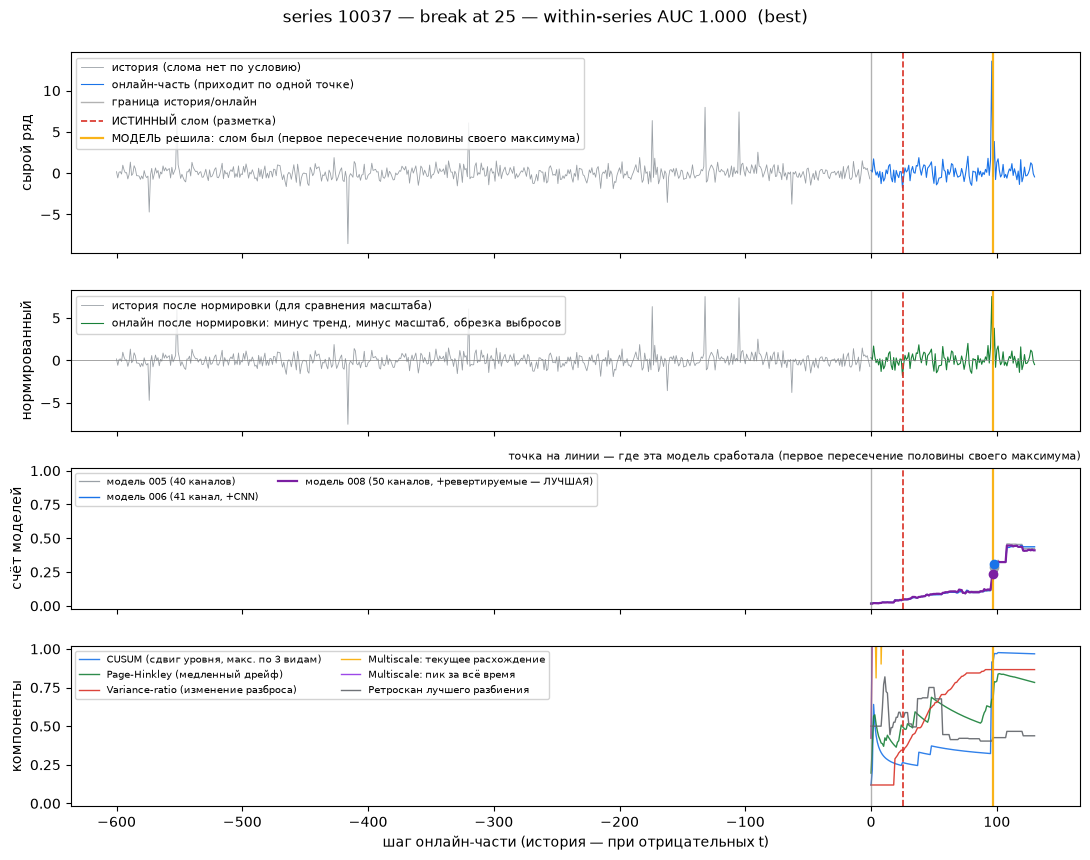

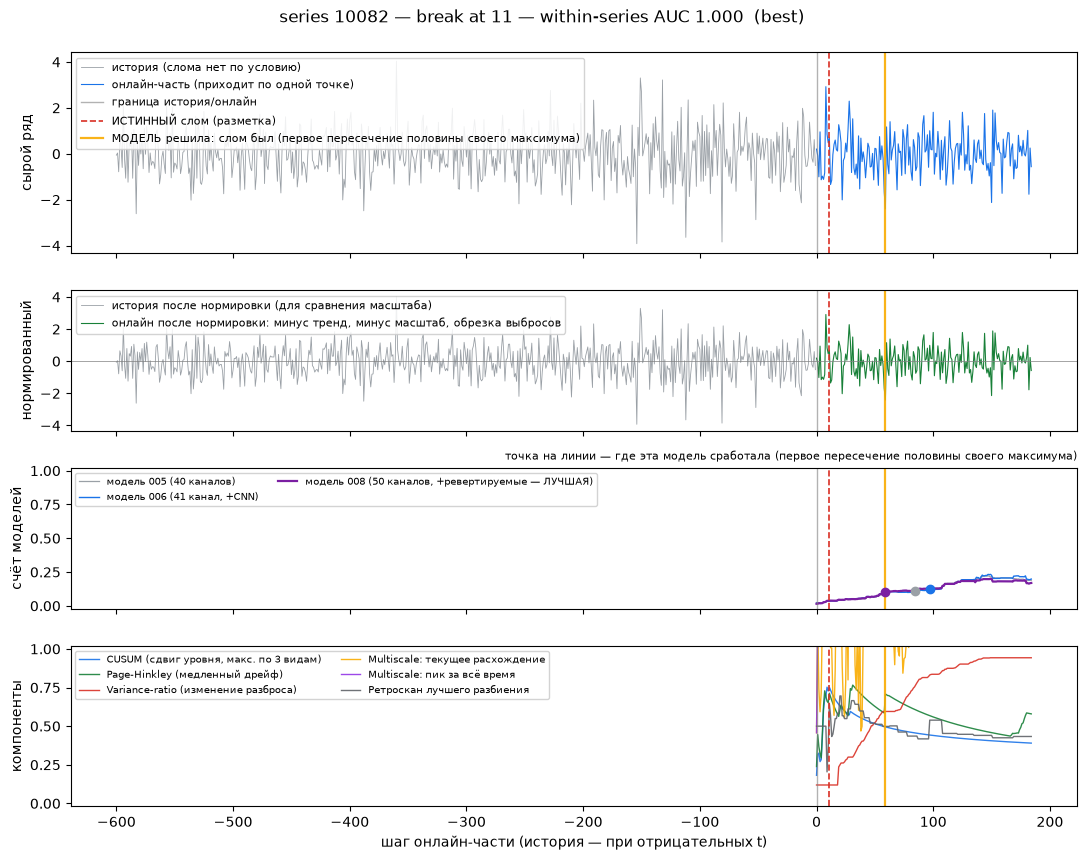

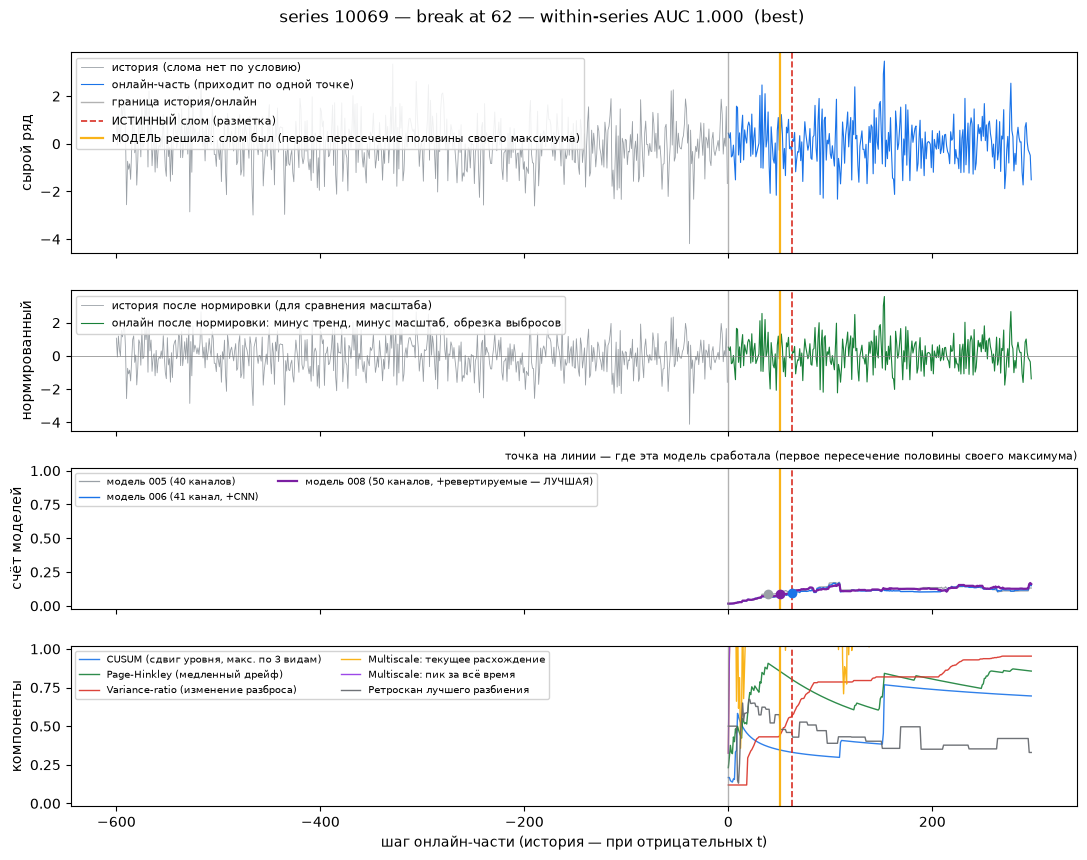

In [5]:
ids = list(broken.index)
for sid in ids[:3]:
    show(sid, "  (best)")

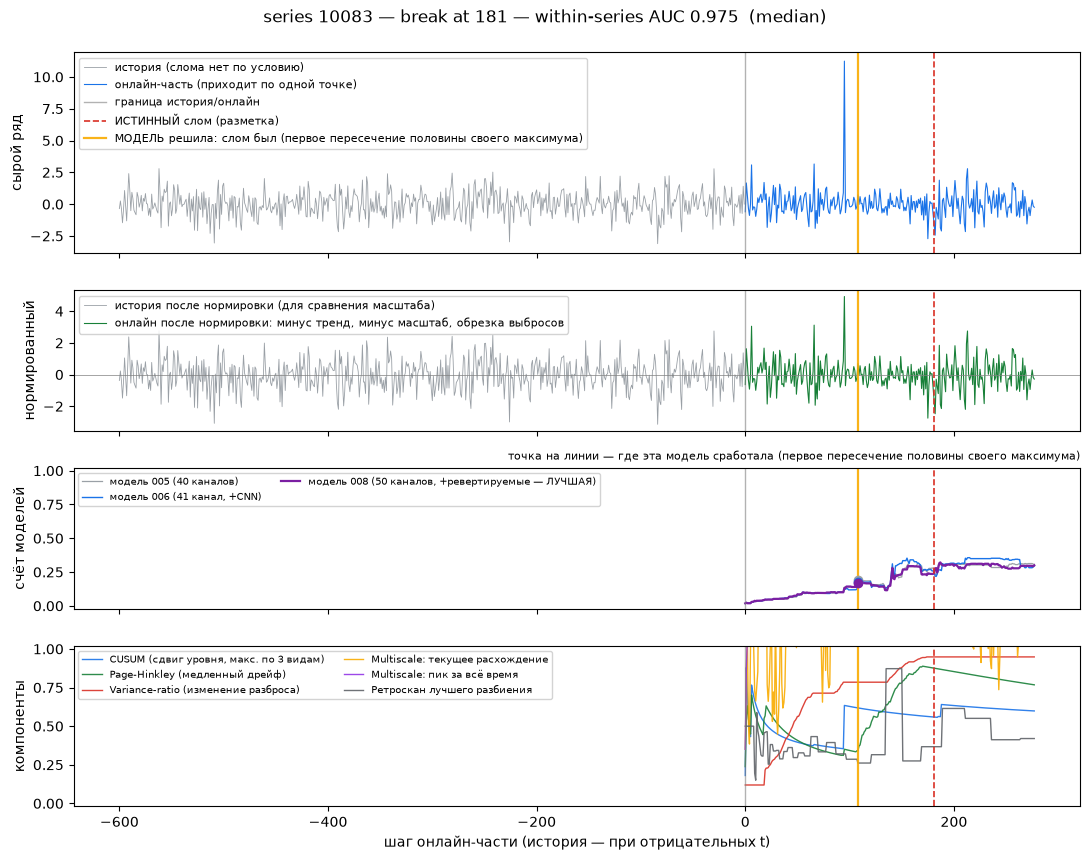

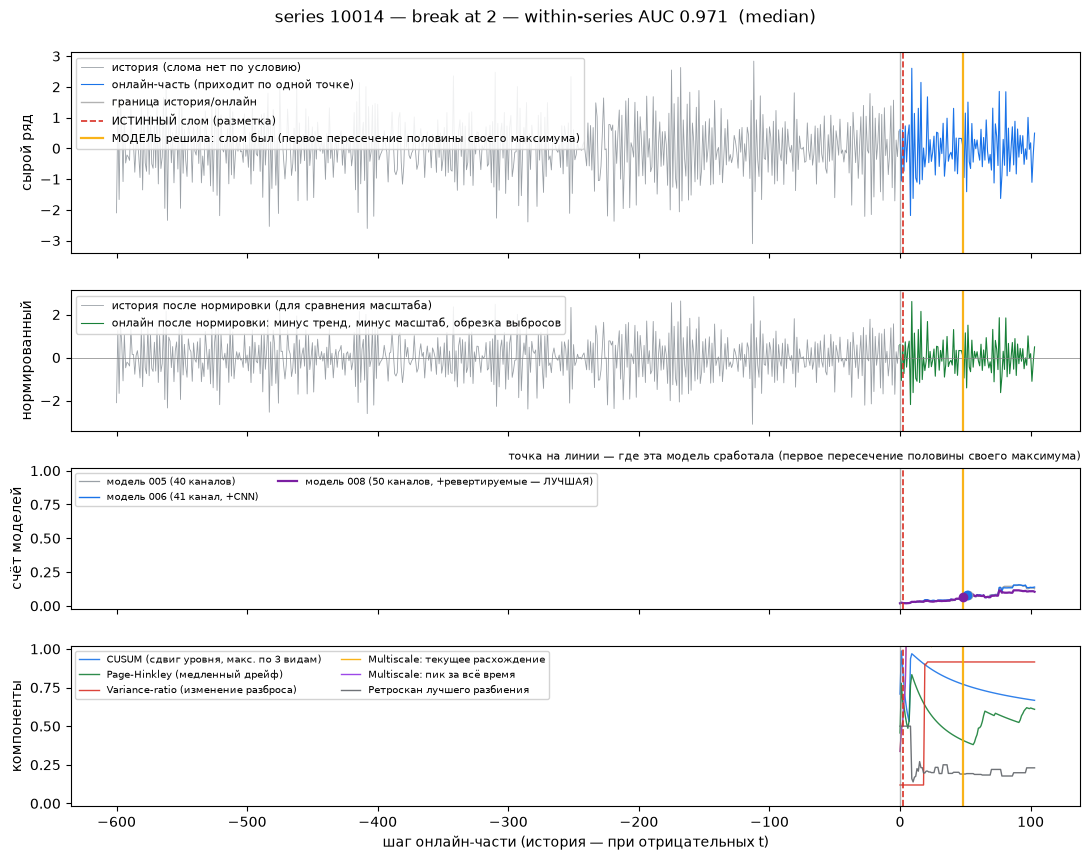

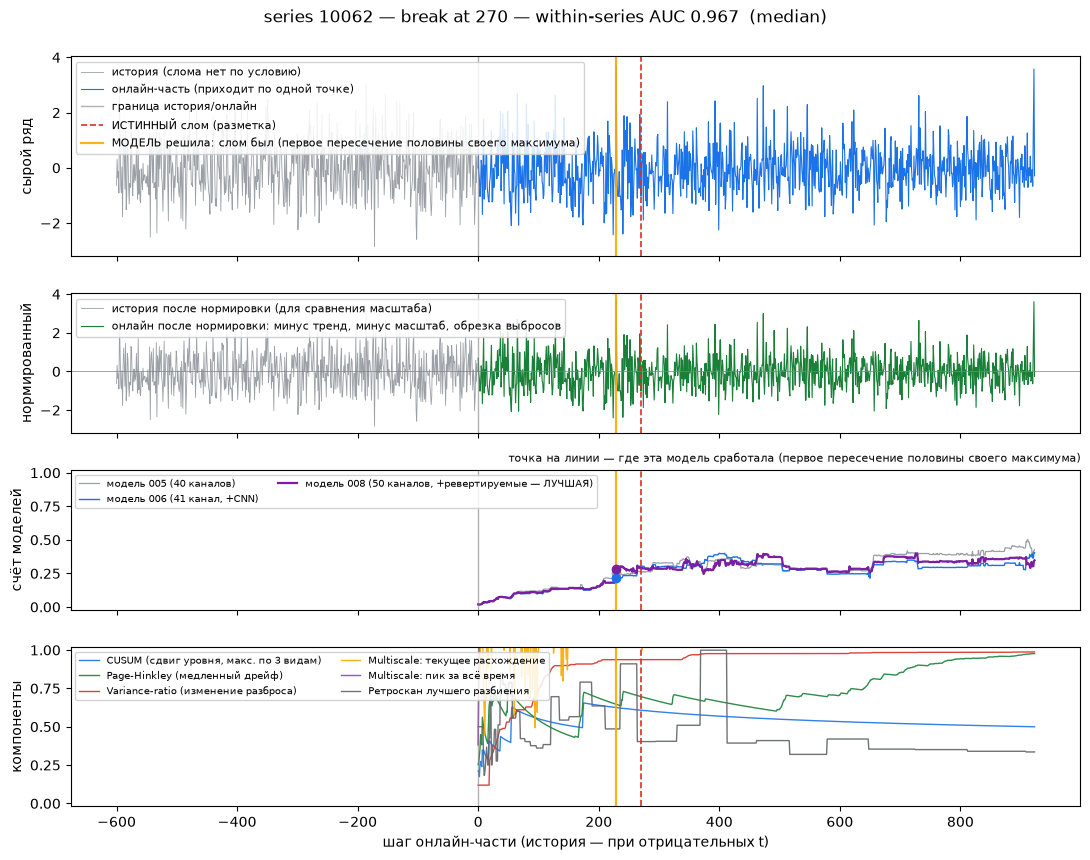

In [6]:
mid = len(ids) // 2
for sid in ids[mid - 1 : mid + 2]:
    show(sid, "  (median)")

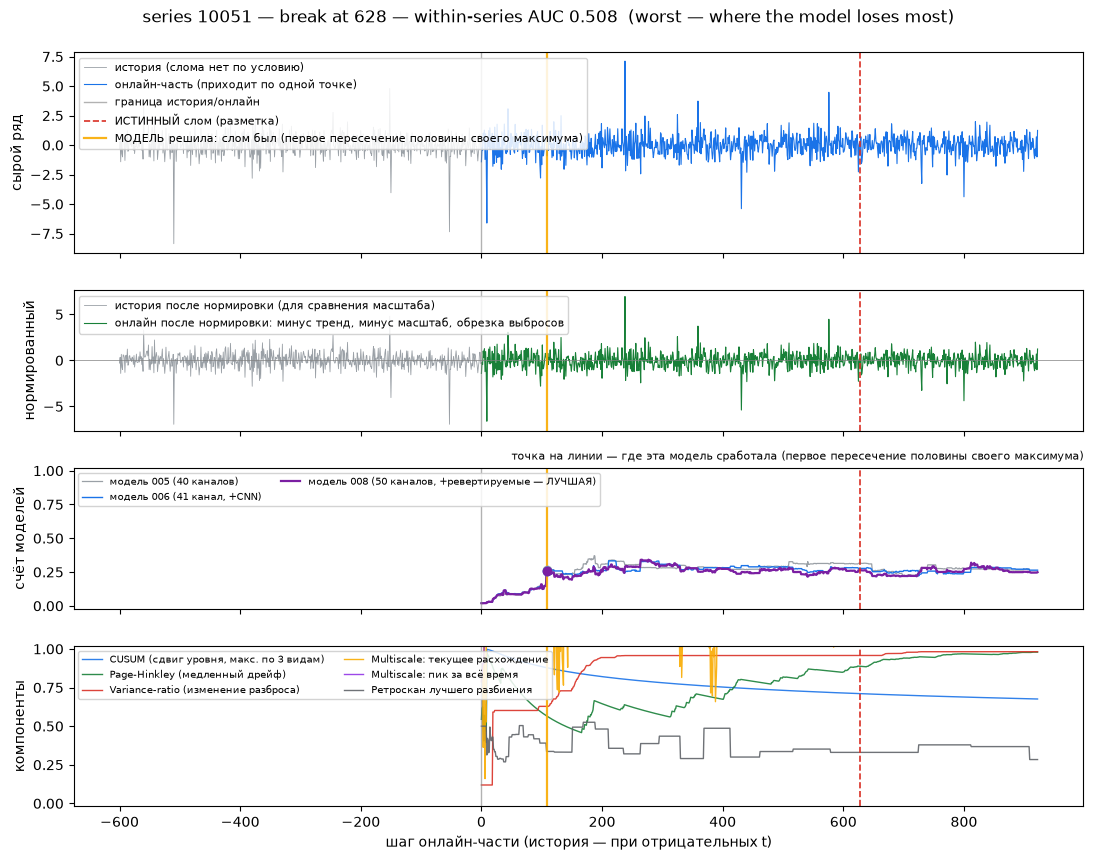

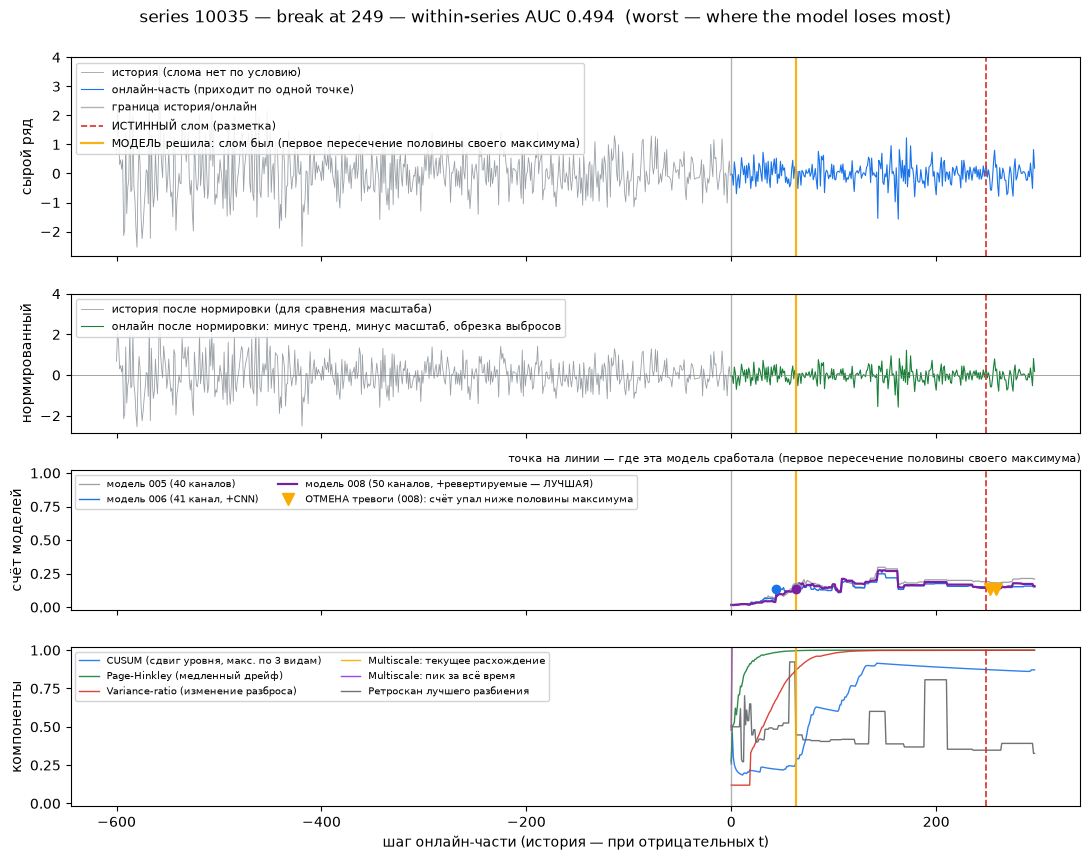

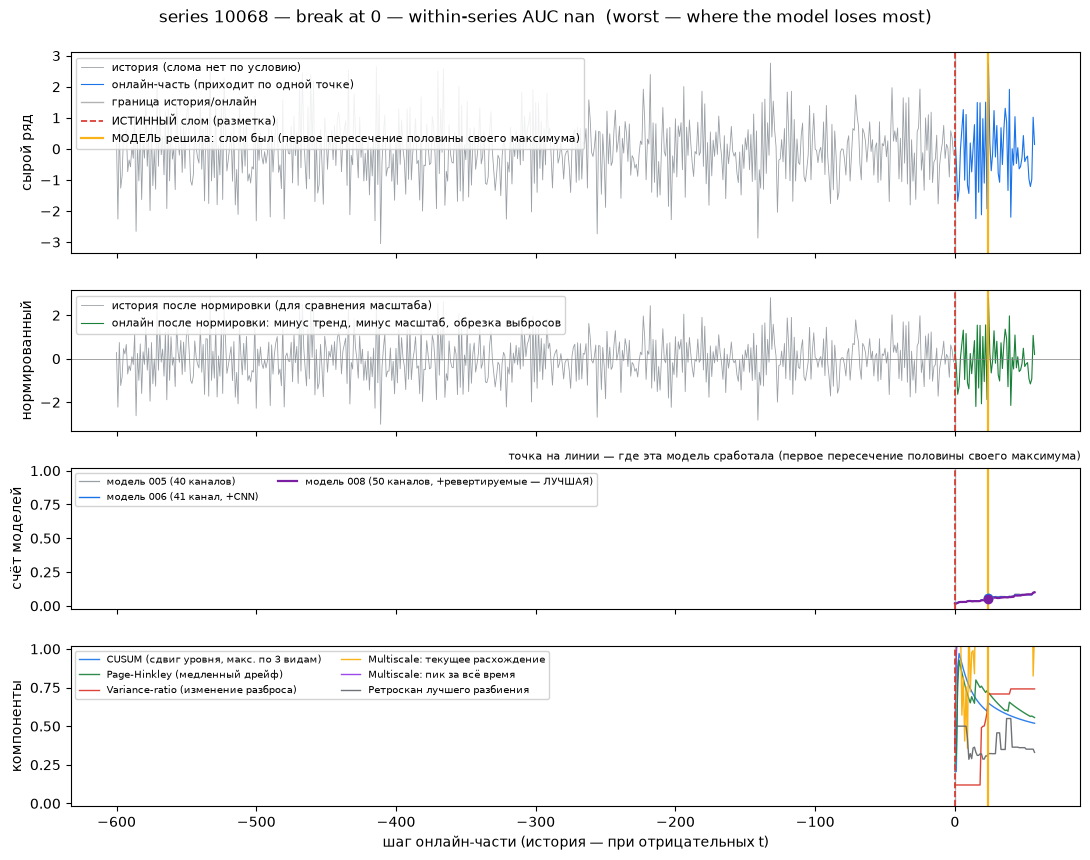

In [7]:
for sid in ids[-3:]:
    show(sid, "  (worst — where the model loses most)")

## Unbroken series: the false alarms

No red line exists; anything the score does here is a mistake. The three
highest-scoring clean series are the model's worst false alarms.

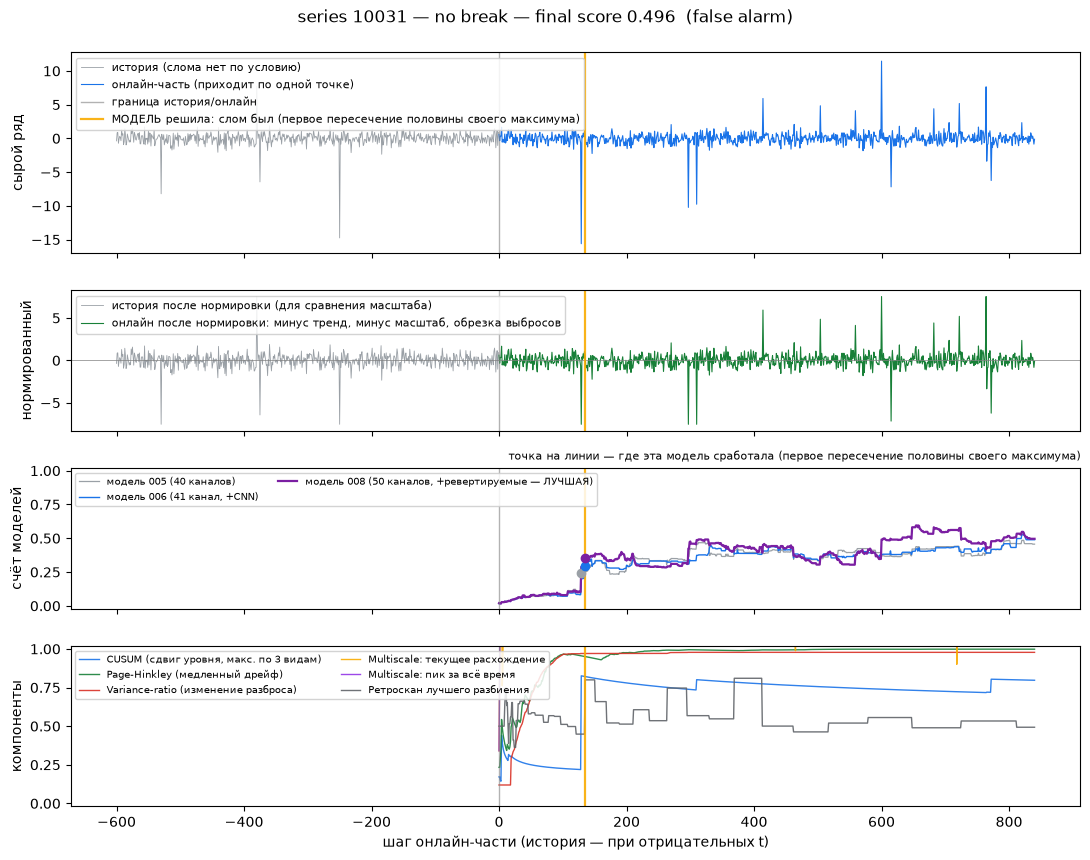

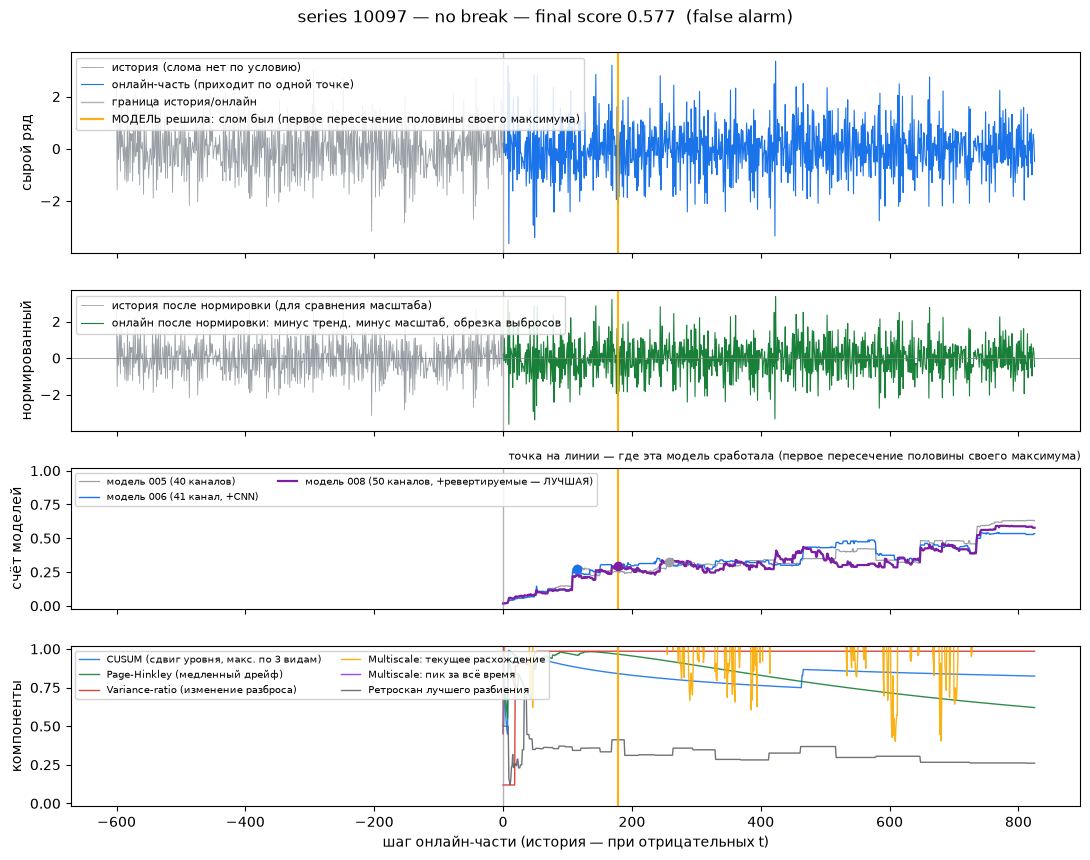

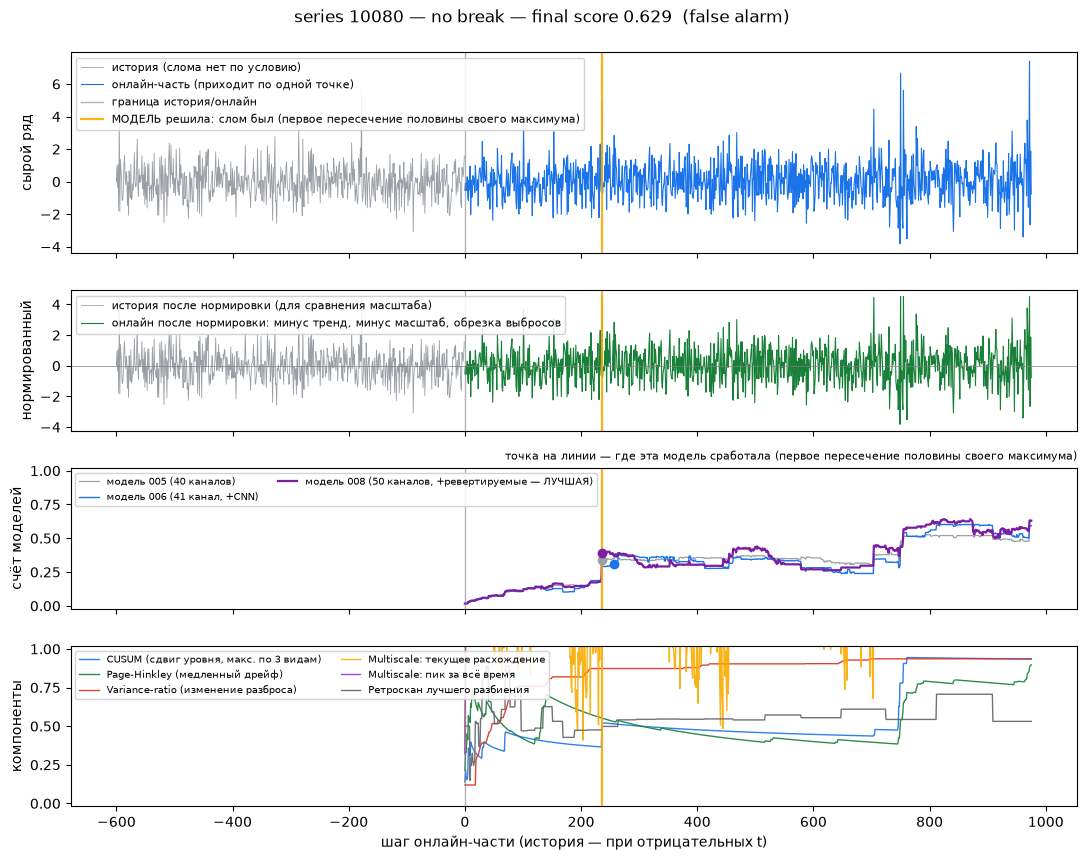

In [8]:
for sid in list(clean.index)[-3:]:
    show(sid, "  (false alarm)")

## Which kinds of series are hard

Median within-series AUC of the broken series, split at the median of each
history property. A large gap names a hypothesis; a flat pair says that axis
does not matter.

,low half,high half,split at
trend strength,0.955,0.992,0.051
dispersion,0.990,0.955,1.000
autocorrelation,0.969,0.980,0.027
tail weight,0.969,0.976,0.208
break position,0.995,0.925,205.000
online length,0.993,0.927,498.000


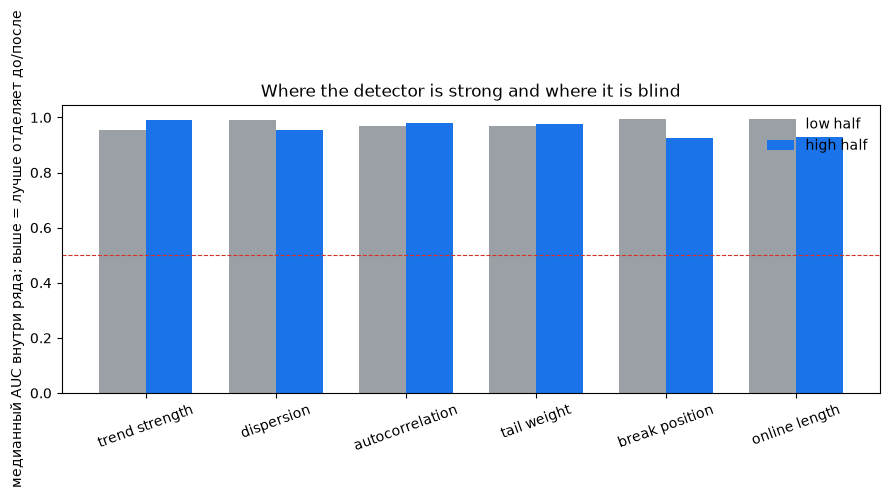

In [9]:
splits = {}
b = table[table.broken]
for col, name in [("trend", "trend strength"), ("sd", "dispersion"),
                  ("rho", "autocorrelation"), ("kurt", "tail weight"),
                  ("tau", "break position"), ("n_online", "online length")]:
    m = b[col].median()
    low, high = b[b[col] <= m], b[b[col] > m]
    splits[name] = (low.quality.median(), high.quality.median(), m)
frame = pd.DataFrame(splits, index=["low half", "high half", "split at"]).T
display(frame.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
xpos = np.arange(len(frame))
ax.bar(xpos - 0.18, frame["low half"], width=0.36, label="low half", color="#9aa0a6")
ax.bar(xpos + 0.18, frame["high half"], width=0.36, label="high half", color="#1a73e8")
ax.set_xticks(xpos, frame.index, rotation=20)
ax.set_ylabel("медианный AUC внутри ряда; выше = лучше отделяет до/после")
ax.axhline(0.5, color="#d93025", lw=0.8, ls="--")
ax.legend(frameon=False)
ax.set_title("Where the detector is strong and where it is blind")
plt.tight_layout(); plt.show()

## Reading list for the next model

The bars above are the hypothesis generator: every axis with a visible gap is a
question — what channel would close it — and every worst-gallery figure is a
concrete series to reason about. The notebook regenerates from
`scripts/build_analysis_notebook.py`; edits belong there.